### 🎯 Phase 6: Popularity Prediction Engine
Objective: Train an XGBoost Regressor to predict a song's popularity score (0-100) based on its audio features, age, and artist/language encoding.

Model: XGBoost (Extreme Gradient Boosting) - the industry standard for tabular regression.

In [1]:
# Ensure ML libraries are installed in this kernel
!uv pip install xgboost scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Premium Plot Theme
sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print("✅ Imports successful")

Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Checked 2 packages in 36ms
✅ Imports successful


In [2]:
# Load ML Ready Data
DATA_PATH = Path("../data/processed/indian_songs_ml_ready.parquet")
df = pd.read_parquet(DATA_PATH)

# Define Features (X) and Target (y)
TARGET = 'popularity'
FEATURES = [col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

# Train/Test Split (80% Train, 20% Test, Random State for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]:,} rows")
print(f"Testing Set:  {X_test.shape[0]:,} rows")
print(f"Features used: {FEATURES}")

Training Set: 27,999 rows
Testing Set:  7,000 rows
Features used: ['danceability', 'acousticness', 'energy', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms', 'release_year', 'years_since_release', 'language_target_enc', 'artist_target_enc']


In [3]:
# Initialize XGBoost Regressor
# We use modest hyperparameters to start to prevent extreme overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=300,      # Number of trees
    learning_rate=0.05,    # Step size shrinkage
    max_depth=6,           # Depth of trees
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Train the model!
print("Training XGBoost Model...")
xgb_model.fit(X_train, y_train)
print("✅ Training Complete!")

Training XGBoost Model...
✅ Training Complete!


📊 Model Performance on Test Set:
RMSE: 21.36 popularity points
R² Score: 5.03%


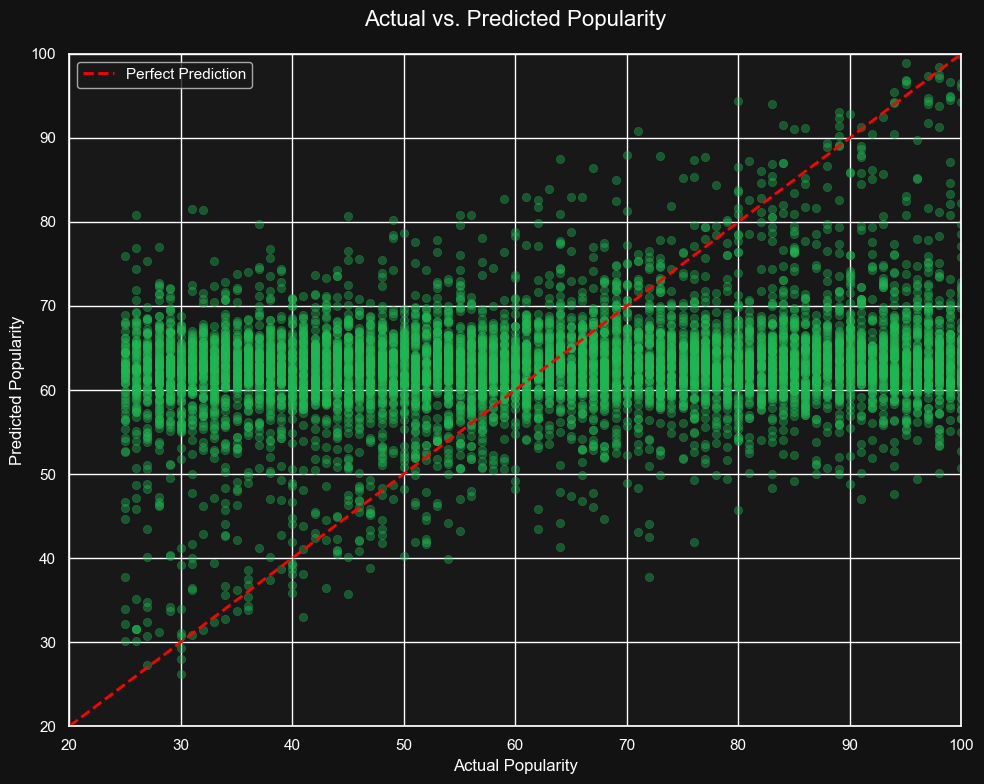

In [4]:
# Predict on the unseen test set
y_pred = xgb_model.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 Model Performance on Test Set:")
print(f"RMSE: {rmse:.2f} popularity points")
print(f"R² Score: {r2:.2%}")

# Visualize: Actual vs Predicted
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='#1DB954', edgecolor=None)

# Add a "perfect prediction" line
plt.plot([0, 100], [0, 100], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Popularity', fontsize=16, pad=20)
plt.xlabel('Actual Popularity', fontsize=12)
plt.ylabel('Predicted Popularity', fontsize=12)
plt.xlim(20, 100) # Remember our 25 floor!
plt.ylim(20, 100)
plt.legend()
plt.tight_layout()
plt.show()